In [2]:
import sys
sys.path.append("..")

In [3]:
from _css import ToricCode
from _channel import Depolarising
from _experiment import BatchGenerator, compare_logicals_wedge

from _draw import *
from _pauli import wedge_dense 

from _decoder import XZ_PymatchDecoder, BruteForceDecoder

import numpy as np

from tqdm import tqdm


import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
L = 3
code = ToricCode(L)

brute_decoder = BruteForceDecoder(code, None)
mwpm_decoder = XZ_PymatchDecoder(code, None)

In [5]:
def evaluate_decoder_prefomance(ps, decoder, code, b_size):
    error_stat = np.zeros(len(ps))
    for j, p in tqdm(enumerate(ps)):
        noise_model = Depolarising(2*L**2, (p/3.,p/3.,p/3.))
        
        decoder.evaluate_log_prob = noise_model.log_prob
        batch_generator = BatchGenerator(code, noise_model)
        
        noise, syndrome, logical = batch_generator.generate_batch(b_size)
        logicals_decoded = decoder.decode2logical(syndrome)
        
        error_stat[j], _ = compare_logicals_wedge(logicals_decoded, logical)
    
    p = error_stat / b_size
    var_p = p * (1 - p) / b_size
    return p, var_p

In [ ]:
ps = np.linspace(0.01, 0.01*40+0.01, 41)
b_size = int(1e3)

brute_stat = evaluate_decoder_prefomance(ps, brute_decoder, code, b_size)
mwmp_stat = evaluate_decoder_prefomance(ps, mwpm_decoder, code, b_size)

30it [45:02, 90.04s/it]

In [ ]:
L = 2
code = ToricCode(L)
brute_decoder = BruteForceDecoder(code, None)
brute_stat_2 = evaluate_decoder_prefomance(ps, brute_decoder, code, b_size)


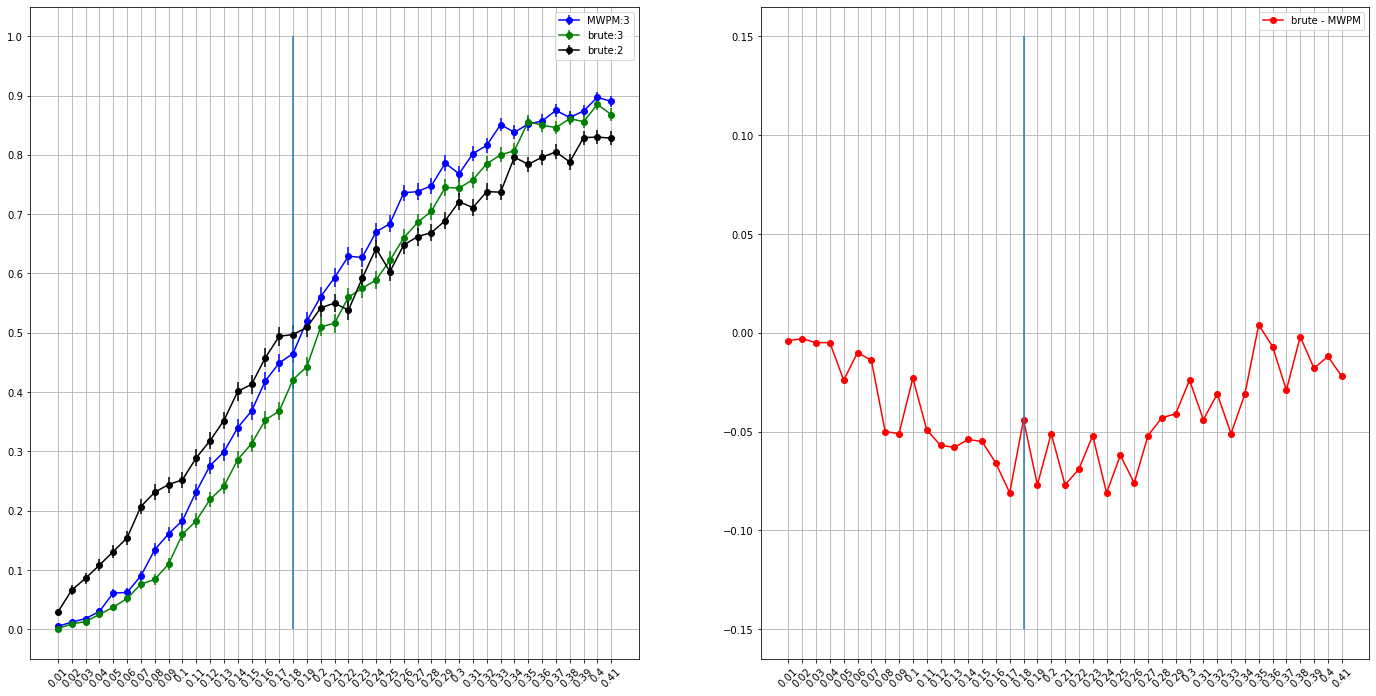

In [12]:
fig, ax = plt.subplots(1,2, figsize=(24,12), sharex=True)

ax[0].errorbar(x=ps, y=mwmp_stat[0] ,yerr=np.sqrt(mwmp_stat[1]), color='blue', label='MWPM:3', marker='o');
ax[0].errorbar(x=ps, y=brute_stat[0], yerr=np.sqrt(brute_stat[1]), color='green', label='brute:3', marker='o');
ax[0].errorbar(x=ps, y=brute_stat_2[0], yerr=np.sqrt(brute_stat_2[1]), color='black', label='brute:2', marker='o');
ax[1].plot(ps, brute_stat[0] - mwmp_stat[0], 'o-', color='red', label='brute - MWPM');

for a in ax.flatten():
    a.set_xticks(ps)
    a.set_xticklabels(np.round(a.get_xticks(), 3), rotation = 45)
    a.legend();
    a.grid(True)
ax[0].set_yticks(np.linspace(0,1,11));
ax[0].vlines(0.18, 0, 1);
ax[1].vlines(0.18, -0.15, 0.15);